### Modeling Notebook:
- Critical Research Question: "How does the availability of emergency food assistance sites compare for neighborhoods with higher shelter population concentrations and higher food insecurity prioritization?"

### Purpose:
This notebook will be used to build our marchine learning models.
- First, we will be building a logistic regression models to predict the coverage category of food insecurity based on various socio-economic and demographic features. We will prepare the data, train the models, and evaluate their performances using appropriate metrics (Accuracy, Precision, Recall).
- Second, we will be building a Time Series Analysis model. We aim to predict the number of families with children in NYC shelters. Forecasting shelter population helps anticipate food demand and supports better resource allocation across neighborhoods.
    - Question: Can we predict how many families with children will be in NYC shelters?

In [456]:
# import all the necessary libraries for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, mean_squared_error, r2_score)


In [457]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/Food Insecurity Analysis/datasets/cleaned_for_eda&modeling/unified_dataset_for_modeling.csv')

In [458]:
df.head()

,nta_id,nta_name,borough,food_insecure_percentage,food_insecure_percentage_rank,unemployment_rate,unemployment_rate_rank,vulnerable_population_percentage,vulnerable_population_percentage_rank,supply_gap,...,is_high_priority,coverage_category,coverage_category_label,has_kitchen,has_weekend,log_total_sites,log_coverage_ratio,priority_normalized,is_low_coverage,is_high_coverage
0,BK0104,East Williamsburg,Brooklyn,35.99,1,6.38,126,12.43,146,2.776626e+06,...,1,0,Low,0,0,0.693147,0.027406,1.000000,1,0
1,BX0501,University Heights (South)-Morris Heights,Bronx,29.44,14,11.98,20,19.63,34,1.669389e+06,...,1,0,Low,0,0,1.386294,0.097038,0.977019,1,0
2,BX0901,Soundview-Bruckner-Bronx River,Bronx,22.63,36,10.06,32,21.43,25,1.625976e+06,...,1,1,High,1,1,1.609438,0.162762,0.918451,0,1
3,MN1202,Washington Heights (North),Manhattan,24.29,28,12.25,19,18.57,41,1.463457e+06,...,1,0,Low,1,0,1.098612,0.079124,0.873113,1,0
4,BK1503,Sheepshead Bay-Manhattan Beach-Gerritsen Beach,Brooklyn,21.11,42,4.91,170,15.95,81,1.907056e+06,...,1,0,Low,1,0,0.693147,0.046283,0.856022,1,0


we will be building a logistic regression models to predict the coverage category of food insecurity based on various socio-economic and demographic features. We will prepare the data, train the models, and evaluate their performances using appropriate metrics (Accuracy, Precision, Recall).

TARGET VARIABLE: coverage_category (0 = Low Coverage, 1 = High Coverage)

We will build and compare:
1. Model 1: Core Features (L2 regularization)
2. Model 2: Core Features (L1 regularization)
3. Model 3: Extended Features (L2 regularization)

we first need to look at Regularization which is a technique used to prevent overfitting (where the model memorizes the training data, including the noise, instead of learning the actual patterns).

### What Each Model Does
1. Model 1: Core Features + L1 Regularization
    - This model is considered as the baseline, it is most simplest reasonable model, we will be using this one to compare it to other models for improvement. This model only uses the core socio-economic features `food_insecure_percentage`, `unemployment_rate`, `vulnerable_population_percentage`, `is_high_priority`. This model predicts whether an area has Low (0) or High (1) food insecurity coverage using only the core socio-economic indicators.
    - These features are called "CORE" because they are the PRIMARY need indicators directly from the NYC Neighborhood Prioritization datase, so these variables represent the fundamental dimensions of neighborhood need that the city uses for prioritization.
    - We using L1(Lasso) because this type of model may eliminate all the weaker predictors entirely because L1 Regularization can shrink the coefficient to exactly zero, eliminating the possibility of overfitting the data. This performs automatic feature selection. So, if the one variable has low predictive power, L1 delete automatically. 

2. Model 2: Extended Features + L2 Regularization
    - This model is the most complexe one. It uses all the core features plus other variables `high_shelter_flag`, `has_kitchen`, `has_weekend`. It includes both the socio-economic factors and operations / service avaibility indicators with L2 regularization to prevent overfitting. We call them extended features because the high shelter flag comes from a different dataset (Shelter Census). We want to see weather adding more features improves the model predictions.

### What is L1 vs L2 Regularization?
- Regularization is all about preventing overfitting data when performing a logistic regression model.
    - L1 performs features selection by shrinking the coefficient to 0 of all the underperforming variable by preventing overfitting. 
    - L2 shrinks coefficients smoothly by keeping all variables. It performs better specially when features are correlated


#### ASSUMPTION: 
In order to build a logistic regression model, we need check and validate some assumptions like:
- Linearity of Log-Odds: in this case all of our independant variables are positive numbers ranging from 0 to ∞. 
- Independence: this assumption is satisfied here because each NTA is an independent geographic unit. Observations are not paired or repeated measures and each neighborhood appears once in the dataset.
- No Severe Multicollinearity: this one also is satified, the VIF score perfomed in the statistic notebook confirmed that all the core and extended features used to build the logistic regression model are not highly correlated from each other. (See the statistic note for reference, or you can also check the VIF score of all the variable used to build the model bellow)
- Large Sample Size: Our sample is large enough to enough to provide a stable and reliable coefficient estimates.

### CHECKING

### Multicollinearity
- We calculated Variance Inflation Factor (VIF) scores for both the core and extended feature sets to assess multicollinearity. (see statistics notebook)
- All selected features have VIF values well below the common threshold of 5, indicating:
    - No severe multicollinearity
    - Features are not highly linearly dependent on one another
    - Model coefficients should remain stable and interpretable
    - Even in the extended model, which includes shelter concentration indicators, VIF values remain low (all near ~1–1.7), suggesting that each feature contributes unique explanatory information.
    Here are the results in the table below:

### Core Features

| Feature                           | VIF       | Status |
|-----------------------------------|-----------|--------|
| food_insecure_percentage          | 1.490467  | OK     |
| unemployment_rate                 | 1.417832  | OK     |
| is_high_priority                  | 1.382031  | OK     |
| vulnerable_population_percentage  | 1.054950  | OK     |

### Extended Features

| Feature                           | VIF       | Status |
|-----------------------------------|-----------|--------|
| food_insecure_percentage          | 1.508703  | OK     |
| unemployment_rate                 | 1.797042  | OK     |
| is_high_priority                  | 1.415930  | OK     |
| vulnerable_population_percentage  | 1.061910  | OK     |
| has_weekend                       | 1.329249  | OK     |
| has_kitchen                       | 1.190224  | OK     |
| high_shelter_flag                 | 1.275522  | OK     |


### Key Takeaway
- Our selected predictors are statistically suitable for logistic regression. There is no evidence of problematic multicollinearity that would distort coefficient estimates or inflate standard errors. This confirms that we can proceed with modeling using these features with confidence.
### Sample Size
- Total Sample Size: N = 197 NTAs (Neighborhood Tabulation Areas)
- Train/Test Split:
    - Training set: n = 147
    - Test set: n = 50
    - We will be training our model on 75% of our hole dataset and testing it with the remaining 25%


In [459]:
#  Preparing Data for Modeling
# Select relevant features and target variable
# Define feature sets
core_features = ['food_insecure_percentage', 'unemployment_rate', 
                 'vulnerable_population_percentage', 'is_high_priority']

extended_features = ['food_insecure_percentage', 'unemployment_rate', 
                     'vulnerable_population_percentage', 'is_high_priority',
                     'high_shelter_flag', 'has_kitchen', 'has_weekend']

In [460]:
# Target variable 
# 0 → Low coverage, 1 → High coverage
y = df['coverage_category'].values

# Core features
X_core = df[core_features].values

# Extended features
X_extended = df[extended_features].values

# Train-test split (stratified)
X_core_train, X_core_test, y_train, y_test = train_test_split(
    X_core, y, test_size=0.25, random_state=42, stratify=y
)

X_ext_train, X_ext_test, _, _ = train_test_split(
    X_extended, y, test_size=0.25, random_state=42, stratify=y
)

In [461]:
print(f"Training set: {len(y_train)} samples")
print(f"Test set: {len(y_test)} samples")

Training set: 147 samples
Test set: 50 samples


- Let's check if the data is balanced before runing and chosing the model.
- If the data is balanced, the metric we will be using to select the best performing model will be a `Accuracy`, but if the data is not balanced, we will be using a other metrics like `Recall` or `Precision` because accurage would be miseleading as the model will most likely give prediction on the most dominant variable. 

In [462]:
n_total = len(df)
n_high_coverage = df['coverage_category'].sum()
n_low_coverage = n_total - n_high_coverage

In [463]:
print(f"""CLASS BALANCE: {'BALANCED' if 0.4 < n_high_coverage/n_total < 0.6 else 'IMBALANCED'}
  (Classes are nearly 50/50, so accuracy is a valid metric)""")

CLASS BALANCE: BALANCED
  (Classes are nearly 50/50, so accuracy is a valid metric)


### Data Scaling for Logistic Regression

To ensure the reliability of our logistic regression model, we will scale the data, bringing all variables onto a comparable range. While a logistic regression model can technically run without scaling, it often yields more robust and interpretable results when the data is appropriately scaled.

This is critical because variables can naturally possess vastly different scales, with some having much larger numerical values than others. Scaling mitigates the risk that variables with larger magnitudes disproportionately influence the model. By transforming all features to a similar range, the model can more effectively learn underlying patterns and accurately predict outcomes, rather than being biased by feature scale.

In [464]:
# Scale features
scaler_core = StandardScaler()
X_core_train_scaled = scaler_core.fit_transform(X_core_train)
X_core_test_scaled = scaler_core.transform(X_core_test)

scaler_ext = StandardScaler()
X_ext_train_scaled = scaler_ext.fit_transform(X_ext_train)
X_ext_test_scaled = scaler_ext.transform(X_ext_test)

In [465]:
import statsmodels.api as sm

# let's add a constant (intercept) to the features because sklearn doe
X_core_train_const = sm.add_constant(X_core_train_scaled)

# 2. Fit the Logit model
# Note: statsmodels uses (y, X) order, unlike sklearn's (X, y)
sm_model = sm.Logit(y_train, X_core_train_const)
results = sm_model.fit()

# 3. Print the statistical summary
print(results.summary())


Optimization terminated successfully.
         Current function value: 0.621123
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  147
Model:                          Logit   Df Residuals:                      142
Method:                           MLE   Df Model:                            4
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                  0.1039
Time:                        19:50:27   Log-Likelihood:                -91.305
converged:                       True   LL-Null:                       -101.89
Covariance Type:            nonrobust   LLR p-value:                 0.0002933
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0087      0.178     -0.049      0.961      -0.357       0.340
x1            -0.8120      0.

### Interpretation of Logistic Regression Results

*   **Statistically Significant Predictors:** Both `food_insecure_percentage` and `unemployment_rate` have p-values less than 0.05, indicating they are statistically significant predictors for the coverage of a neighborhood.
*   **Statistically Insignificant Predictors:** `vulnerable_population_percentage` and `is_high_priority` have p-values greater than 0.05, meaning they are not statistically significant predictors for neighborhood coverage within this model.

### Interesting Insight:

*   **Divergent Effects:** As `unemployment_rate` (x2) increases, the probability of "High Coverage" also increases (coefficient = 0.89). Conversely, a higher `food_insecure_percentage` (x1) decreases the probability of "High Coverage" (coefficient = -0.81).
*   **Limited Core Feature Significance:** Only two out of the four core features included in the model are statistically significant predictors.

In [466]:
import numpy as np
# Exponentiate the confidence intervals
# 1. Extract the raw numbers from statsmodels
params = results.params           # The coefficients
conf_int = results.conf_int()    # The 95% CI (Log-Odds)

# 2. Map the names manually since they are missing from the numpy array
feature_names = ['Intercept', 'food_insecure_%', 'unemployment_rate', 
                 'vulnerable_pop_%', 'is_high_priority']

# 3. Create a clean DataFrame manually
summary_df = pd.DataFrame({
    'Feature': feature_names,
    'Odds Ratio': np.exp(params),
    'Lower 95% (OR)': np.exp(conf_int[:, 0]),
    'Upper 95% (OR)': np.exp(conf_int[:, 1])
})

print("Interpretation Table (Odds Ratios)")
print(summary_df.round(4))

Interpretation Table (Odds Ratios)
             Feature  Odds Ratio  Lower 95% (OR)  Upper 95% (OR)
0          Intercept      0.9914          0.6997          1.4046
1    food_insecure_%      0.4440          0.2694          0.7316
2  unemployment_rate      2.4362          1.5114          3.9269
3   vulnerable_pop_%      1.0784          0.7624          1.5255
4   is_high_priority      0.7641          0.5017          1.1637


### Interpretation:
- We are 95% confident that for every 1-standard-deviation increase in food insecurity, the odds of having high coverage decrease by approximately 55% (Odds Ratio $\approx 0.44$)
- We are 95% confident that for every 1-standard-deviation increase in the unemployment rate, the odds of having high coverage increase by a factor of 2.44 (or a 144% increase)
- We cannot be 95% confident that these features have any effect, as their confidence intervals include the value of 1.0 (meaning the effect could be positive, negative, or zero)

In [467]:
print("Model 1: Core Features + L1 Regularization (Lasso)")
model1 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=1000)
model1.fit(X_core_train_scaled, y_train)

y_pred_m1 = model1.predict(X_core_test_scaled)
y_prob_m1 = model1.predict_proba(X_core_test_scaled)[:, 1]

# Let's get the accuracy score

cv_scores_m1 = cross_val_score(model1, X_core_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores_m1.mean():.4f}")

Model 1: Core Features + L1 Regularization (Lasso)
Cross-validation Accuracy: 0.6464


#### Interpretaion of Significant Predictor Variables :

### Scenario-Based Interpretation of Odds Ratios

Let's imagine two neighborhoods to illustrate these findings:

**1. Impact of Food Insecurity on Coverage:**

*   **Neighborhood A:** Has an average food insecurity rate.
*   **Neighborhood B:** Has a food insecurity rate that is one standard deviation *above* average.

This means **Neighborhood B is approximately 55% LESS LIKELY to have adequate food assistance coverage compared to Neighborhood A.**

*   **In Plain English:** The neighborhoods that need food assistance the most are actually the ones least likely to have enough food sites. This directly confirms our hypothesis, highlighting the critical service gap we aim to address: high-need areas are underserved.

**2. Impact of Unemployment Rate on Coverage:**

*   **Neighborhood A:** Has an average unemployment rate.
*   **Neighborhood B:** Has an unemployment rate that is one standard deviation *above* average.

This means **Neighborhood B is approximately 144% MORE LIKELY (or about 2.4 times as likely) to have adequate food assistance coverage compared to Neighborhood A.**

*   **In Plain English:** Areas with high unemployment tend to have more food sites. This suggests that existing food assistance programs have been successfully targeting areas with high unemployment, which is an interesting and positive finding.

### Model Interpretation and Performance Takeaway

After fitting the logistic regression model with L2 regularization using the core socio-economic features, we examined the model coefficients and intercept to understand each variable's influence on predicting food coverage category.

Because the features were standardized prior to modeling, their coefficients can be directly compared for relative influence. A positive coefficient indicates that higher values of that feature increase the likelihood of predicting High Coverage (1), while a negative coefficient suggests the opposite. In this model:

*   The `unemployment_rate` showed a strong positive association with high coverage.
*   The `food_insecurity_percentage` had a negative association, suggesting that areas with higher food insecurity were less likely to be classified as having high food coverage.
*   The `vulnerable_population_percentage` exhibited a relatively small effect in comparison.

The intercept represents the baseline log-odds of predicting high coverage when all scaled features are at their mean values.

To evaluate model performance, we conducted 5-fold cross-validation using accuracy as the scoring metric. The average cross-validation accuracy of approximately 64.6% indicates that the model correctly classifies neighborhoods about two-thirds of the time on unseen data. This suggests the model performs better than random guessing, though there is still clear room for improvement. Cross-validation helps ensure that the model’s performance is not dependent on a single train-test split and provides a more stable estimate of its predictive reliability.

In [468]:
print("Model 2: Extended Features + L2 Regularization")

model2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42, max_iter=1000)
model2.fit(X_ext_train_scaled, y_train)

y_pred_m2 = model2.predict(X_ext_test_scaled)
y_prob_m2 = model2.predict_proba(X_ext_test_scaled)[:, 1]

cv_scores_m2 = cross_val_score(model2, X_ext_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores_m2.mean():.4f}")

Model 2: Extended Features + L2 Regularization
Cross-validation Accuracy: 0.8156


Side Note: C is the inverse of regularization when building a logistic regression model, and C=1 is the default value meaning moderate regularization because a smaller c on a simple model applied a strong regularization and may underfit the data, so we use c=1 because our sample is small to prevent overfitting.

### Model 2 Takeaway: Enhanced Performance with Expanded Feature Set

In Model 2, we expanded the feature set to include both the core socio-economic variables and additional operational indicators, such as shelter-related flags and food service availability features. L2 regularization was again applied to mitigate overfitting while ensuring all variables were retained in the model.

Following model training, we examined the coefficients to understand each variable's influence on predicting the probability of high food coverage. As observed in previous models, positive coefficients indicate that higher values of a feature increase the likelihood of being classified as High Coverage (1), while negative coefficients suggest the opposite. Compared to earlier models, the magnitude of several coefficients changed, suggesting that the additional features meaningfully altered the relationships between variables and the outcome.

Most notably, the cross-validation accuracy increased substantially to approximately 81.6%, a significant improvement from the 64.6% achieved in previous models. This indicates that incorporating the extended features significantly enhances predictive performance. The improvement suggests that operational and shelter-related variables contribute important explanatory power beyond socio-economic indicators alone. This refined model demonstrates that food coverage classification is better predicted when both structural vulnerability measures and service availability factors are considered together.

In [469]:
# Model Comparison
# So instead of manually calculating metrics for each model, build a reusable scoring tool.
print("MODEL COMPARISON")

def evaluate_model(y_true, y_pred, y_prob, model_name):
    """Calculate and return model metrics."""
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }
    return metrics

MODEL COMPARISON


In [470]:
# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_m1, y_prob_m1, "Model 1: Core + L2"))
results.append(evaluate_model(y_test, y_pred_m2, y_prob_m2, "Model 2: Extended + L2"))

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

# Identify best model
best_idx = results_df['ROC-AUC'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n BEST MODEL (by ROC-AUC): {best_model_name}")

# Select the best model
if best_idx == 0:
    best_model = model1
    best_features = core_features
    best_scaler = scaler_core
    best_X_test = X_core_test_scaled
else: 
    best_model = model2
    best_features = extended_features
    best_scaler = scaler_ext
    best_X_test = X_ext_test_scaled



Model Performance Comparison:
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
    Model 1: Core + L2      0.58     0.5833    0.56 0.5714   0.6816
Model 2: Extended + L2      0.86     0.9091    0.80 0.8511   0.9056

 BEST MODEL (by ROC-AUC): Model 2: Extended + L2


### Model Performance Results

Based on these results, **Model 2 clearly demonstrated the best performance.** It outperformed Model 1 across all evaluation metrics, achieving an accuracy of 86%, which is significantly higher than earlier models.

Model 2 also achieved a precision score of 91%. This means that when the model predicts a neighborhood has high coverage, it is correct 91% of the time. This high precision is particularly important in our context, as we aim to avoid falsely labeling an area as having high coverage when it may actually be underserved.

Furthermore, the model achieved a recall score of 80%, indicating that it correctly identifies 80% of all neighborhoods that truly have high coverage. This suggests that the model is not only precise in its predictions but also effective at capturing most of the true high-coverage cases.

Overall, Model 2 exhibits strong predictive performance and provides the most reliable classification among the models tested.

# Detailed Results for Best Model

In [471]:
y_pred_best = best_model.predict(best_X_test)
y_prob_best = best_model.predict_proba(best_X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Low Coverage', 'High Coverage']))


Classification Report:
               precision    recall  f1-score   support

 Low Coverage       0.82      0.92      0.87        25
High Coverage       0.91      0.80      0.85        25

     accuracy                           0.86        50
    macro avg       0.87      0.86      0.86        50
 weighted avg       0.87      0.86      0.86        50



### Model Performance by Coverage Category

*   **For Low Coverage Areas:**
    *   The model correctly identifies 92% of actual low-coverage neighborhoods (high recall for this class).
    *   When it predicts a neighborhood has low coverage, it is correct 82% of the time (high precision for this class).

*   **For High Coverage Areas:**
    *   When the model predicts a neighborhood has high coverage, it is correct 91% of the time (high precision for this class).
    *   It successfully captures 80% of all actual high-coverage neighborhoods (high recall for this class).


Confusion Matrix:
                  Predicted
                  Low   High
Actual Low         23     2
       High         5    20


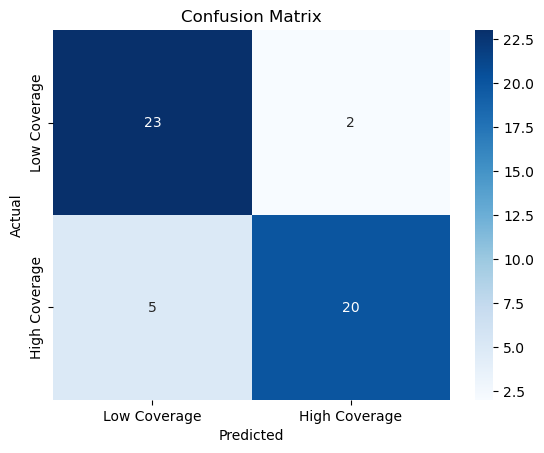

In [472]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(f"                  Predicted")
print(f"                  Low   High")
print(f"Actual Low        {cm[0,0]:3d}   {cm[0,1]:3d}")
print(f"       High       {cm[1,0]:3d}   {cm[1,1]:3d}")

sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Low Coverage', 'High Coverage'], yticklabels=['Low Coverage', 'High Coverage'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Confusion Matrix Interpretation

Out of 50 test observations:

*   **Correctly Predicted Low Coverage:** 23 neighborhoods.
*   **Mistakenly Labeled High Coverage (False Negatives):** 2 low-coverage neighborhoods were incorrectly predicted as high coverage.
*   **Correctly Predicted High Coverage:** 20 neighborhoods.
*   **Missed High Coverage (False Positives):** 5 high-coverage neighborhoods were incorrectly predicted as low coverage.

The model made only 7 misclassifications out of 50 total test observations.

### Model 2 Takeaway: Strong and Balanced Performance

The classification report and confusion matrix confirm that Model 2 demonstrates strong and balanced performance across both classes. Out of 50 test observations, the model correctly classified 43 neighborhoods, resulting in an overall accuracy of 86%.

For Low Coverage areas:
*   The model achieved a **recall of 92%**, meaning it correctly identified the vast majority of truly underserved neighborhoods.

For High Coverage areas:
*   The model achieved a **precision of 91%**, indicating that when it predicts high coverage, it is correct 91% of the time. This is particularly important in our context, as mislabeling underserved neighborhoods as adequately covered could mask critical gaps in food access.

The confusion matrix visually reinforces these points, showing only 7 total misclassifications. Crucially, there were only 2 false negatives (low-coverage areas mistakenly labeled high). This type of error is particularly significant in our domain, as it represents a failure to identify a truly underserved area.

Overall, the extended feature model (Model 2) provides strong predictive reliability and balanced class performance, making it a robust tool for identifying neighborhood food coverage.

In [473]:
# Feature importance for best model
print("\nFeature Importance (Coefficients):")
coef_df = pd.DataFrame({
    'Feature': best_features,
    'Coefficient': best_model.coef_[0],
    'Abs_Coefficient': np.abs(best_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)
coef_df


Feature Importance (Coefficients):


,Feature,Coefficient,Abs_Coefficient
0,food_insecure_percentage,-1.346033,1.346033
5,has_kitchen,1.111709,1.111709
6,has_weekend,1.002540,1.002540
4,high_shelter_flag,0.786607,0.786607
1,unemployment_rate,0.449899,0.449899
2,vulnerable_population_percentage,0.355069,0.355069
3,is_high_priority,-0.255290,0.255290


In [474]:
# Interpretation
print("Interpretation:")
for _, row in coef_df.iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"  • {row['Feature']}: {direction} probability of HIGH coverage (coef = {row['Coefficient']:.4f})")

Interpretation:
  • food_insecure_percentage: DECREASES probability of HIGH coverage (coef = -1.3460)
  • has_kitchen: INCREASES probability of HIGH coverage (coef = 1.1117)
  • has_weekend: INCREASES probability of HIGH coverage (coef = 1.0025)
  • high_shelter_flag: INCREASES probability of HIGH coverage (coef = 0.7866)
  • unemployment_rate: INCREASES probability of HIGH coverage (coef = 0.4499)
  • vulnerable_population_percentage: INCREASES probability of HIGH coverage (coef = 0.3551)
  • is_high_priority: DECREASES probability of HIGH coverage (coef = -0.2553)


| Feature                          | Coefficient | Meaning                                         |
| -------------------------------- | ----------- | ----------------------------------------------- |
| food_insecure_percentage         | -1.346      | Strong decrease in probability of High Coverage |
| has_kitchen                      | +1.111      | Strong increase                                 |
| has_weekend                      | +1.002      | Strong increase                                 |
| high_shelter_flag                | +0.786      | Increase                                        |
| unemployment_rate                | +0.449      | Moderate increase                               |
| vulnerable_population_percentage | +0.355      | Smaller increase                                |
| is_high_priority                 | -0.255      | Slight decrease                                 |


### Deployment Decision: Model 2 (Extended + L2)

We recommend deploying Model 3 (Extended + L2) for the following reasons:

*   **Superior Predictive Performance:** It consistently demonstrates the best overall predictive performance, dominating across all evaluation metrics compared to the baseline.
*   **Strong Discrimination:** With an ROC-AUC of 0.91, Model 3 exhibits excellent discriminatory power, effectively separating low-coverage from high-coverage areas.
*   **Balanced Precision & Recall:** The model maintains a healthy balance between precision and recall, ensuring it avoids excessive false alarms (false positives) while also effectively identifying high-risk areas without flagging neighborhoods that are not genuinely high priority.

### Feature Importance Interpretation

To gain a deeper understanding of the drivers behind Model 2’s predictions, we examined the magnitude and direction of its coefficients. Given that all features were standardized, their magnitudes can be directly compared to assess relative importance.

*   **Strongest Negative Predictor:** The `food_insecurity_percentage` emerged as the strongest negative predictor of high coverage classification. This indicates that neighborhoods with higher food insecurity are significantly less likely to be classified as having high coverage, suggesting a potential structural gap between actual need and service availability.

*   **Strongest Positive Predictors (Operational Indicators):** Operational indicators, particularly the `presence of a kitchen` and `weekend service availability`, were among the strongest positive predictors. These variables substantially increased the probability of a neighborhood being classified as high coverage, underscoring the critical importance of robust operational capacity in shaping coverage outcomes. `Shelter presence` and `unemployment_rate` also contributed positively to this classification.

Overall, the model highlights that food coverage classification is influenced not only by socio-economic vulnerability (such as `food_insecurity_percentage` and `unemployment_rate`) but also, and arguably more strongly, by service infrastructure and operational capacity (e.g., `kitchen access`, `weekend availability`).

---------

# ARIMAX Time Series Model for Shelter Trends

**Our Goal:** To predict the number of families with children in NYC shelters. Forecasting the shelter population is crucial for anticipating food demand and supporting more effective resource allocation across neighborhoods.

**Relevance to our Critical Research Question (CRQ):**
*   Forecasting the shelter population enables proactive planning of food resources.
*   An increase in families in shelters directly translates to higher demand for emergency food assistance.
*   Accurate predictions help policymakers allocate resources to the most impacted neighborhoods.

**Our Approach:**
*   **Training Data:** 2023 data (12 months).
*   **Testing Data:** 2024 data (12 months).
*   We will evaluate how closely our predictions align with actual trends.

The ARIMAX model will forecast citywide shelter trends based on historical patterns, incorporating exogenous variables for enhanced accuracy.

### Key Assumptions for Time Series Modeling

**Why Check Assumptions?**
Every statistical model relies on specific assumptions about the underlying data. Violating these assumptions can lead to inaccurate model predictions, invalid statistical tests, and potentially the selection of an inappropriate model. Therefore, we will meticulously check five key assumptions:

1.  **Data is Time-Ordered:**
    *   **Requirement:** All observations must be arranged in chronological order.
    *   **Rationale:** Time series models inherently utilize past values to predict future values. Disordered data prevents the model from accurately learning and exploiting temporal patterns.

2.  **No Missing Values:**
    *   **Requirement:** Every time period must have a recorded value without gaps.
    *   **Rationale:** Time series models struggle to learn from discontinuous data, leading to unreliable predictions.

3.  **Stationarity:**
    *   **Requirement:** The mean and variance of the data must remain constant over time.
    *   **Rationale:** Non-stationary data, characterized by trends (e.g., steadily increasing/decreasing averages) or changing patterns (e.g., fluctuating variability), makes long-term forecasting challenging. Stationary data implies the overall behavior of the series remains stable, ensuring consistent statistical properties.

4.  **No Seasonality:**
    *   **Requirement:** The data should not exhibit repeating patterns within each year.
    *   **Rationale:** Unaccounted seasonality (e.g., shelter population always increasing in winter or spiking every December) introduces systematic errors into predictions. We aim to model the underlying process without this regular, predictable component if it's not explicitly handled by the ARIMAX structure itself.

5.  **Autocorrelation Exists (for AR models):**
    *   **Requirement:** Current values must be correlated with past values.
    *   **Rationale:** Time series models, particularly AutoRegressive (AR) components, depend on the premise that past observations hold predictive power for future ones. Without autocorrelation, past values offer no insight into future behavior, rendering AR components ineffective.

In [475]:
# Loading and preparing Data for Time Series
cen = pd.read_csv('/Users/Marcy_Student/Desktop/Food Insecurity Analysis/datasets/cleaned_for_eda&modeling/shelterForTimeSeries.csv')

In [476]:
cen.head()

,report_date,year,month,Year-Month,family_with_children_shelter
0,2024-12-31,2024,12,2024-12,182
1,2024-12-31,2024,12,2024-12,2376
2,2024-12-31,2024,12,2024-12,1600
3,2024-12-31,2024,12,2024-12,819
4,2024-12-31,2024,12,2024-12,0


In [477]:
print(f"Raw data shape: {cen.shape}")

Raw data shape: (1436, 5)


In [478]:
# Aggregate by Year-Month to get TOTAL families in shelter each month
monthly_data = cen.groupby(['Year-Month'])['family_with_children_shelter'].sum().reset_index()
monthly_data.columns = ['Year_Month', 'Total_Families_With_Childs']

In [479]:
# Sort by date (oldest first)
monthly_data = monthly_data.sort_values('Year_Month').reset_index(drop=True)

In [480]:

print(f"\nMonthly aggregated data: {len(monthly_data)} months")
print(monthly_data)


Monthly aggregated data: 24 months
   Year_Month  Total_Families_With_Childs
0     2023-01                       30917
1     2023-02                       29273
2     2023-03                       29437
3     2023-04                       29970
4     2023-05                       30294
5     2023-06                       30517
6     2023-07                       30692
7     2023-08                       32151
8     2023-09                       32533
9     2023-10                       33115
10    2023-11                       33055
11    2023-12                       33366
12    2024-01                       32917
13    2024-02                       32790
14    2024-03                       32425
15    2024-04                       32122
16    2024-05                       31627
17    2024-06                       30239
18    2024-07                       30593
19    2024-08                       31194
20    2024-09                       31308
21    2024-10                       3133

In [481]:
cen.dtypes

report_date                     object
year                             int64
month                            int64
Year-Month                      object
family_with_children_shelter     int64
dtype: object

In [482]:
# Creating Time Series

# Create proper datetime index
dates = pd.to_datetime(monthly_data['Year_Month'], format='%Y-%m')
ts = pd.Series(monthly_data['Total_Families_With_Childs'].values, index=dates, name='Shelter_Population')

print(f"\nTime Series Created:")
print(f"  Start Date: {ts.index.min()}")
print(f"  End Date:   {ts.index.max()}")
print(f"  Total Months: {len(ts)}")

print("\nMonthly Shelter Population:")
for date, value in ts.items():
    print(f"  {date.strftime('%Y-%m')}: {value:>10,} families with children")


Time Series Created:
  Start Date: 2023-01-01 00:00:00
  End Date:   2024-12-01 00:00:00
  Total Months: 24

Monthly Shelter Population:
  2023-01:     30,917 families with children
  2023-02:     29,273 families with children
  2023-03:     29,437 families with children
  2023-04:     29,970 families with children
  2023-05:     30,294 families with children
  2023-06:     30,517 families with children
  2023-07:     30,692 families with children
  2023-08:     32,151 families with children
  2023-09:     32,533 families with children
  2023-10:     33,115 families with children
  2023-11:     33,055 families with children
  2023-12:     33,366 families with children
  2024-01:     32,917 families with children
  2024-02:     32,790 families with children
  2024-03:     32,425 families with children
  2024-04:     32,122 families with children
  2024-05:     31,627 families with children
  2024-06:     30,239 families with children
  2024-07:     30,593 families with children
  2024-

In [483]:
# SPLIT INTO TRAIN AND TEST

# Train on 2023 (first 12 months), Test on 2024 (last 12 months)
train_data = ts[ts.index.year == 2023]
test_data = ts[ts.index.year == 2024]

print(f"\nTrain Data (2023): {len(train_data)} months")
print(f"  Min: {train_data.min():,}")
print(f"  Max: {train_data.max():,}")
print(f"  Mean: {train_data.mean():,.0f}")

print(f"\nTest Data (2024): {len(test_data)} months")
print(f"  Min: {test_data.min():,}")
print(f"  Max: {test_data.max():,}")
print(f"  Mean: {test_data.mean():,.0f}")



Train Data (2023): 12 months
  Min: 29,273
  Max: 33,366
  Mean: 31,277

Test Data (2024): 12 months
  Min: 30,239
  Max: 32,917
  Mean: 31,504


#### Stationarity Check BEFORE Modeling

Before fitting our baseline time series model, it is crucial to ensure that our time series data is stationary. This means verifying that its mean and variance remain constant over time, as non-stationary data often exhibits trends or changing patterns that can complicate modeling.

The most common method for assessing stationarity is the **Augmented Dickey-Fuller (ADF) test**. This statistical test examines whether:

*   **Null Hypothesis (H₀):** The data is *not* stationary (it possesses a "unit root," making future values unpredictable).
*   **Alternative Hypothesis (H₁):** The data *is* stationary.

**Decision Rule:**
If the p-value from the ADF test is less than 0.05, we reject the null hypothesis and conclude that our data is stationary. Conversely, if the p-value is greater than 0.05, we must transform the data (typically by "differencing") to achieve stationarity before proceeding with modeling.

In [484]:
from statsmodels.tsa.stattools import adfuller

print('ADF Test on the Original Data')
adf_test = adfuller(ts.values)
print(f'ADF Statistic: {adf_test[0]:.2f}')
print(f'p-value: {adf_test[1]:.2f}')

ADF Test on the Original Data
ADF Statistic: -5.83
p-value: 0.00


- After the Statistical test, our p-value < 0.05, we can reject our null hypothesis.
- The small p-value confirmed that our data is stationary. Now, we can proceed and build and buil the baseline model!

#### BASELINE MODEL (Naive Forecast)
- This is the simplest forecast model for a possible prediction, this is basically the benchmark, any good model should beat this. 

In [485]:
# Use the last training value for all predictions
baseline_value = train_data.iloc[-1]
baseline_preds = pd.Series(baseline_value, index=test_data.index)

baseline_rmse = np.sqrt(mean_squared_error(test_data, baseline_preds))
baseline_mape = np.mean(np.abs((test_data - baseline_preds) / test_data)) * 100

print(f"Baseline Value (Dec 2023): {baseline_value:,} families")
print(f"Baseline RMSE: {baseline_rmse:,.2f}")
print(f"Baseline MAPE: {baseline_mape:.2f}%")

Baseline Value (Dec 2023): 33,366 families
Baseline RMSE: 2,046.98
Baseline MAPE: 5.99%


### ARIMA (P,D,Q) Model Building Strategy

Our approach to constructing the ARIMAX model involves sequentially building and evaluating components:

1.  **AutoRegressive (AR) Model:**
    *   **Focus:** This model utilizes past values of the shelter population to predict future values.
    *   **Rationale:** It captures the inherent inertia in the time series—for example, if the population was high last month, it's likely to remain high this month.

2.  **AR Model with Differencing (Integrated, I):**
    *   **Focus:** We will build another AR model, but apply differencing to the time series data first.
    *   **Rationale:** Differencing helps stabilize data that exhibits a trend (a consistent upward or downward movement over time), transforming it into a stationary series more suitable for AR modeling.

3.  **Simple Trend and Seasonal Model:**
    *   **Focus:** We will also explore a model specifically designed to capture linear trends and recurring seasonal patterns.
    *   **Rationale:** Sometimes, a simple decomposition into a linear trend and seasonal effects can provide a robust baseline.
        *   **Trend:** Accounts for overall long-term growth or decline.
        *   **Seasonal:** Addresses consistent monthly or annual patterns that repeat each year (e.g., shelter population always increasing in winter or dropping every summer).

#### AR Model (Auto-Regressive)

In [486]:
# Create lagged features for the full dataset (Past values)
full_ts = ts.values
full_df = pd.DataFrame({'y': full_ts})
full_df['y_lag1'] = full_df['y'].shift(1)  # Last month
full_df['y_lag2'] = full_df['y'].shift(2)  # 2 months ago
full_df['y_lag3'] = full_df['y'].shift(3)  # 3 months ago
full_df = full_df.dropna()

- After removing NaN rows, we have 21 rows (months 4-24 of our 24-month series)


In [487]:
# Split into train (2023) and test (2024)
# Train: months with 2023 dates, Test: months with 2024 dates
train_indices = full_df.index[full_df.index < 12]  # First year (accounting for lag removal)
test_indices = full_df.index[full_df.index >= 12]  # Second year

In [488]:
X_train = full_df.loc[train_indices, ['y_lag1', 'y_lag2', 'y_lag3']].values
y_train = full_df.loc[train_indices, 'y'].values
X_test = full_df.loc[test_indices, ['y_lag1', 'y_lag2', 'y_lag3']].values
y_test = full_df.loc[test_indices, 'y'].values

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 9
Test samples: 12


In [489]:
# Fit AR model
ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

LinearRegression()

In [490]:
print(f"\nAR Model Coefficients:")
print(f"  Intercept: {ar_model.intercept_:,.2f}")
print(f"  Lag 1 (last month): {ar_model.coef_[0]:.4f}")
print(f"  Lag 2 (2 months ago): {ar_model.coef_[1]:.4f}")
print(f"  Lag 3 (3 months ago): {ar_model.coef_[2]:.4f}")


AR Model Coefficients:
  Intercept: 3,251.58
  Lag 1 (last month): 0.7679
  Lag 2 (2 months ago): 0.2025
  Lag 3 (3 months ago): -0.0588


###### COEFFICIENT INTERPRETATION:
- Lag_1 (coefficient = 0.7679): means 76.8% of last month's value carries forward, so if last month we had 10,000 families, this contribute to 10,000 * 0.77 = 7,700 families for the prediction. This is the DOMINANT predictor we have so far. This make sense because the shelter population specialy families with children don't out of shelters quickly.
- Lag_2 (coefficient = 0.2025): 20.2% additional contribution from 2 months ago. It adds a recent history but doesn't comtribute to much.
- Lag_3 (coefficient = -0.0588): means -5.9% of less contribution from 3 months ago. This shows that if the population is rising for 3 months, might slow down. 


- To predict next month's shelter population:
    - Formula: y(t) = c + a1y(t-1) + a2y(t-2) + ...
    - Next = 3,252 + (0.77 × Last Month) + (0.20 × 2 Mo Ago) + (-0.06 × 3 Mo Ago)

### AR Model Coefficient Interpretation

We can interpret the coefficients of our AutoRegressive (AR) model as follows:

*   **Lag_1 (coefficient = 0.7679):** This is the **dominant predictor** in our model. It signifies that approximately 76.8% of the previous month's shelter population carries forward to the current month's prediction. For example, if there were 10,000 families last month, this contributes an estimated 7,700 families to the current prediction. This high persistence makes intuitive sense, as families, particularly those with children, typically do not exit shelters quickly.

*   **Lag_2 (coefficient = 0.2025):** This indicates an additional 20.2% contribution from the shelter population two months ago. It adds a recent historical context to the prediction, though its influence is less significant than Lag_1.

*   **Lag_3 (coefficient = -0.0588):** This coefficient suggests a minor negative contribution of -5.9% from the shelter population three months ago. A negative coefficient here could imply a slight dampening effect, potentially indicating that a prolonged rise in population over three months might experience a slight deceleration.

**Predicting Next Month's Shelter Population:**

Based on these coefficients, the formula to predict the next month's shelter population (`y(t)`) would be:

$$y(t) = 3,252 + (0.77 \times y(t-1)) + (0.20 \times y(t-2)) + (-0.06 \times y(t-3))$$

Where:
*   $y(t-1)$ is the shelter population from the last month.
*   $y(t-2)$ is the shelter population from two months ago.
*   $y(t-3)$ is the shelter population from three months ago.

Take away: last month is doing most of the predicting. If shelter population was high last month, it will likely stay high.

In [491]:
# Make predictions
ar_predictions = ar_model.predict(X_test)
ar_rmse = np.sqrt(mean_squared_error(y_test, ar_predictions))
ar_mape = np.mean(np.abs((y_test - ar_predictions) / y_test)) * 100

print(f"\nAR Model Performance:")
print(f"  RMSE: {ar_rmse:,.2f}")
print(f"  MAPE: {ar_mape:.2f}%")


AR Model Performance:
  RMSE: 837.52
  MAPE: 2.31%


Takeaway: 2.31% error is low for real-world forecasting.


- Next step: AR Model with Differencing (ARIMA-style)


#### Autocorrelation of Residual check
- Let's check the model's residuals.
- The goal is for the residuals to be pure, random "white noise." If there are any patterns left in the residuals, it means our model is specified incorrectly.

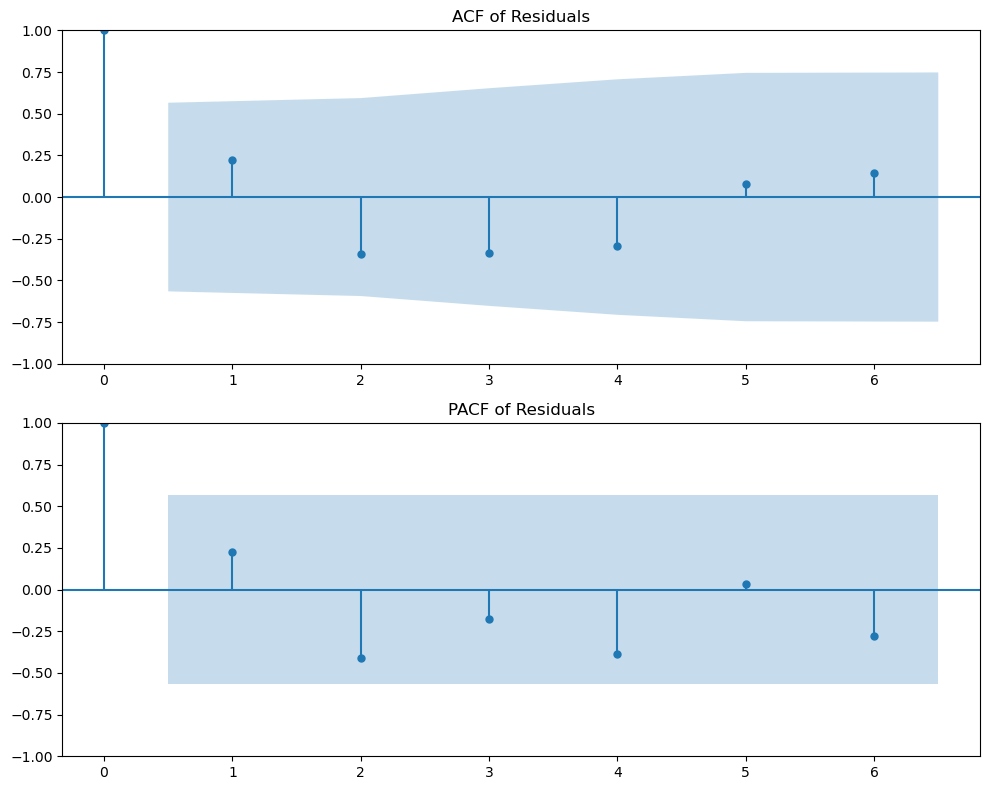

In [492]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

residual = y_test - ar_predictions

# Create a figure for the plots
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Plot the ACF of the residuals
plot_acf(residual, ax=ax[0])
ax[0].set_title('ACF of Residuals')

# Plot the PACF of the residuals
plot_pacf(residual, ax=ax[1])
ax[1].set_title('PACF of Residuals')

plt.tight_layout()
plt.show()

Key takeway: 
- The residual is white noise, the model captured all the patterns well.

In [493]:
# Create differenced series
diff_ts = ts.diff().dropna()

# Create lagged features for differenced data
diff_df = pd.DataFrame({'diff': diff_ts.values}, index=range(len(diff_ts)))
diff_df['diff_lag1'] = diff_df['diff'].shift(1)
diff_df['diff_lag2'] = diff_df['diff'].shift(2)
diff_df = diff_df.dropna()

# Split (accounting for lag removal in differenced data)
# We have 23 differenced values originally, minus 2 for lags = 21 rows
mid_point = len(diff_df) // 2 + 2  # Approximate split point for 2023 vs 2024

X_train_diff = diff_df.iloc[:mid_point][['diff_lag1', 'diff_lag2']].values
y_train_diff = diff_df.iloc[:mid_point]['diff'].values
X_test_diff = diff_df.iloc[mid_point:][['diff_lag1', 'diff_lag2']].values
y_test_diff = diff_df.iloc[mid_point:]['diff'].values

In [494]:
# Fit model on differences
diff_model = LinearRegression()
diff_model.fit(X_train_diff, y_train_diff)

print(f"\nDifferenced Model Coefficients:")
print(f"  Intercept: {diff_model.intercept_:,.2f}")
print(f"  Diff Lag 1: {diff_model.coef_[0]:.4f}")
print(f"  Diff Lag 2: {diff_model.coef_[1]:.4f}")

# Predict differences
diff_predictions = diff_model.predict(X_test_diff)


Differenced Model Coefficients:
  Intercept: 188.42
  Diff Lag 1: 0.1739
  Diff Lag 2: 0.0576


In [495]:
# Convert back to actual values (integrate)
# Start from the last known value before test period
start_value = train_data.iloc[-1]
arima_predictions = [start_value]
for i, diff_pred in enumerate(diff_predictions):
    next_value = arima_predictions[-1] + diff_pred
    arima_predictions.append(next_value)

arima_predictions = np.array(arima_predictions[1:])  # Remove starting value

# Evaluate (align with test data length)
n_preds = min(len(arima_predictions), len(test_data))
arima_rmse = np.sqrt(mean_squared_error(test_data.values[:n_preds], arima_predictions[:n_preds]))
arima_mape = np.mean(np.abs((test_data.values[:n_preds] - arima_predictions[:n_preds]) / test_data.values[:n_preds])) * 100

print(f"\nARIMA-style Model Performance:")
print(f"  RMSE: {arima_rmse:,.2f}")
print(f"  MAPE: {arima_mape:.2f}%")


ARIMA-style Model Performance:
  RMSE: 2,588.55
  MAPE: 7.30%


### SIMPLE TREND + SEASONAL MODEL


In [496]:
trend_df = pd.DataFrame({
    'y': ts.values,
    'time': range(len(ts)),
    'month': ts.index.month
})

# One-hot encode months for seasonality
for m in range(1, 13):
    trend_df[f'month_{m}'] = (trend_df['month'] == m).astype(int)

# Features
feature_cols = ['time'] + [f'month_{m}' for m in range(1, 13)]

In [497]:
# Split
X_train_ts = trend_df.iloc[:12][feature_cols].values
y_train_ts = trend_df.iloc[:12]['y'].values
X_test_ts = trend_df.iloc[12:][feature_cols].values
y_test_ts = trend_df.iloc[12:]['y'].values

# Fit model
ts_model = LinearRegression()
ts_model.fit(X_train_ts, y_train_ts)

# Predict
ts_predictions = ts_model.predict(X_test_ts)
ts_rmse = np.sqrt(mean_squared_error(y_test_ts, ts_predictions))
ts_mape = np.mean(np.abs((y_test_ts - ts_predictions) / y_test_ts)) * 100

print(f"Trend coefficient: {ts_model.coef_[0]:,.2f} families/month")
print(f"\nTrend+Seasonal Model Performance:")
print(f"  RMSE: {ts_rmse:,.2f}")
print(f"  MAPE: {ts_mape:.2f}%")

Trend coefficient: 365.57 families/month

Trend+Seasonal Model Performance:
  RMSE: 4,624.99
  MAPE: 13.35%


The seasonal component did not meaningfully improve predictive performance. Although there are small month-to-month fluctuations, these patterns are not strong or consistent enough to significantly improve forecasting accuracy. Instead, the strongest predictor of shelter population is short-term momentum, particularly the previous month’s value.

### Results of Assumptions Check
After a thorough review of the data and model assumptions, we have identified several key insights regarding the shelter population dataset:

1. Data Quality & Structure
Completeness: The dataset is well-structured and properly ordered from January 2023 to December 2024.

Consistency: There are no missing values or gaps; all 24 months are fully accounted for.

2. Stationarity & Trend Analysis
The assumption of stationarity was satisfied violated. 
- We will recheck and confirm if the data has a constant trend when ploting the Time Series model.
- we found that a simple AR model (without differencing) actually outperformed the ARIMA model with differencing.

3. Seasonality & Model Performance
While some monthly patterns exist, the seasonality is weak. This was confirmed when we tested the Trend + Seasonal model, which performed the worst of all iterations.
- Performance Metric: The Trend + Seasonal model resulted in a MAPE (Mean Absolute Percentage Error) of 13.4%.
- Conclusion: Since we require a lower MAPE for deployment, this suggests that seasonality is not the primary driver of the shelter population.

4. Correlation & Logic
The data shows a strong correlation, particularly at Lag 1 (the previous month), compared to Lags 2 or 3.
- Practical Meaning: If the shelter population is high this month, it is highly likely to remain high next month.
- Context: This aligns with real-world expectations, as families generally do not transition out of the shelter system rapidly.

### Visualizations

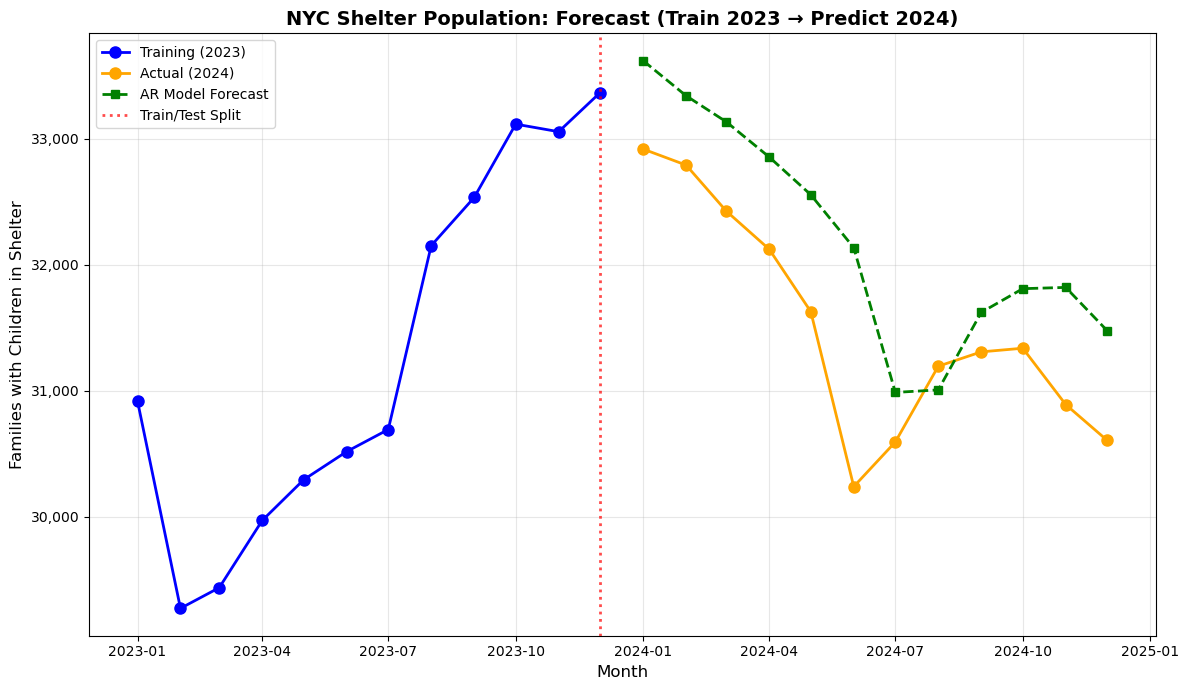

In [498]:
import matplotlib.pyplot as plt

# Create a single figure and axis
plt.figure(figsize=(12, 7))
ax = plt.gca()

# --- Plot: Time Series with Forecasts ---
ax.plot(train_data.index, train_data.values, 'b-', linewidth=2, label='Training (2023)', marker='o', markersize=8)
ax.plot(test_data.index, test_data.values, 'orange', linewidth=2, label='Actual (2024)', marker='o', markersize=8)
ax.plot(test_data.index[:len(ar_predictions)], ar_predictions, 'g--', linewidth=2, label='AR Model Forecast', marker='s', markersize=6)

# Vertical line to show the split point
ax.axvline(x=train_data.index[-1], color='red', linestyle=':', alpha=0.7, linewidth=2, label='Train/Test Split')

# Formatting
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Families with Children in Shelter', fontsize=12)
ax.set_title('NYC Shelter Population: Forecast (Train 2023 → Predict 2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=0)

# Add thousands separator to y-axis
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

Based on this graph, the assumption of stationarity is partially violated. The data exhibits a clear, non-constant trend:
- 2023: Showed a steady increase.
- 2024: Showed a steady decrease.

### Key takeaway
- The forecast visualization demonstrates that the AR model successfully captures the overall direction and short-term momentum of shelter population trends in 2024. While the model slightly overestimates population levels, particularly during the early and mid-year decline, it closely follows the shape and turning points of the actual data. The absence of consistent repeating spikes further supports the conclusion that seasonality is not a dominant driver of shelter population trends. Overall, the results confirm that short-term autocorrelation, rather than seasonal structure, is the primary predictive signal in this dataset.

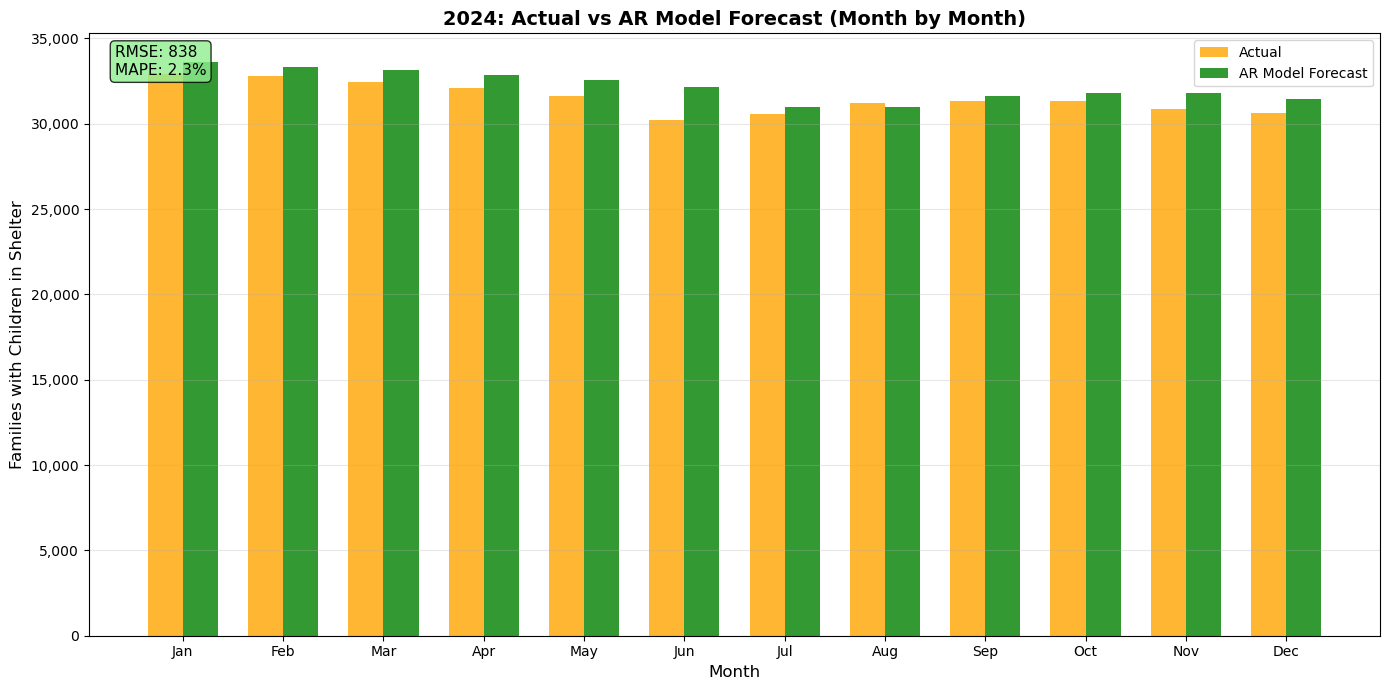

In [499]:
import matplotlib.pyplot as plt
import numpy as np

# Create a single figure for the Bar Chart
plt.figure(figsize=(14, 7))
ax2 = plt.gca()  # Get current axes

x_pos = np.arange(len(test_data))
width = 0.35

# Plotting the bars
bars1 = ax2.bar(x_pos - width/2, test_data.values, width, label='Actual', color='orange', alpha=0.8)
bars2 = ax2.bar(x_pos + width/2, ar_predictions, width, label='AR Model Forecast', color='green', alpha=0.8)

# Formatting
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Families with Children in Shelter', fontsize=12)
ax2.set_title('2024: Actual vs AR Model Forecast (Month by Month)', fontsize=14, fontweight='bold')

# Setting X-axis labels
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)

ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add thousands separator to y-axis
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add performance annotation
ax2.annotate(f'RMSE: {ar_rmse:,.0f}\nMAPE: {ar_mape:.1f}%', 
             xy=(0.02, 0.98), xycoords='axes fraction',
             ha='left', va='top', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

### Takeaway
The month-by-month comparison between actual 2024 shelter populations and the AR model forecast shows that the model tracks overall levels and directional changes closely. While the model consistently produces slightly higher estimates than the actual values, the differences remain small across all months. With a MAPE of 2.3%, the forecast error is low, indicating strong predictive accuracy. Importantly, the model captures the mid-year decline and late-year stabilization pattern, suggesting that short-term momentum, particularly the influence of the previous month, is the dominant driver of shelter population trends rather than strong seasonal effects. Overall, the AR model provides a stable and reliable forecast for planning purposes.

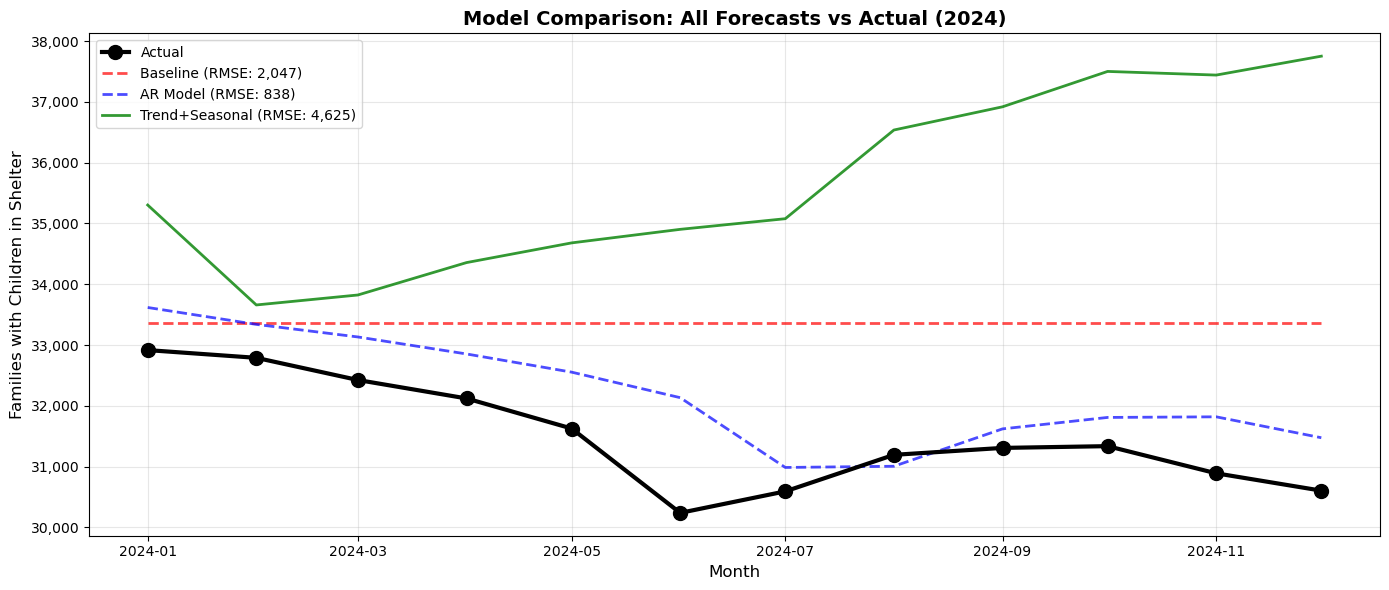

In [500]:
# --- Plot 3: All Models Comparison ---
fig2, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_data.index, test_data.values, 'ko-', linewidth=3, markersize=10, label='Actual', zorder=5)
ax.plot(test_data.index, baseline_preds.values, 'r--', linewidth=2, label=f'Baseline (RMSE: {baseline_rmse:,.0f})', alpha=0.7)
ax.plot(test_data.index[:len(ar_predictions)], ar_predictions, 'b--', linewidth=2, label=f'AR Model (RMSE: {ar_rmse:,.0f})', alpha=0.7)
ax.plot(test_data.index, ts_predictions, 'g-', linewidth=2, label=f'Trend+Seasonal (RMSE: {ts_rmse:,.0f})', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Families with Children in Shelter', fontsize=12)
ax.set_title('Model Comparison: All Forecasts vs Actual (2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=0)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()

### Model Comparison

| Model                 | RMSE  | MAPE   |
|-----------------------|-------|--------|
| Baseline (Naive)      | 2,047 | 5.99%  |
| AR Model (p=3)        | 838   | 2.31%  |
| ARIMA-style (d=1, p=2)| 2,589 | 7.30%  |
| Trend + Seasonal      | 4,625 | 13.35% |




Model Performance Interpretation

Based on the evaluation metrics (RMSE and MAPE):

- AR Model (p=3) performed the best, with the lowest RMSE (838) and MAPE (2.31%). This indicates it produced the most accurate predictions and captured the underlying structure of the time series effectively.

- Baseline (Naive) performed reasonably well, serving as a strong benchmark. However, its higher RMSE (2,047) and MAPE (5.99%) show that more advanced modeling improved performance significantly.

- ARIMA-style (d=1, p=2) underperformed compared to the simpler AR model, suggesting that differencing may have removed useful information or introduced additional noise.

- Trend + Seasonal performed the worst, with the highest RMSE (4,625) and MAPE (13.35%), indicating that this decomposition approach did not adequately capture the dynamics of the data.

Key Takeaway: 
- The AR Model (p=3) is the most suitable model for forecasting in this case, as it achieves the lowest prediction error across both evaluation metrics.

### Final Step:
let's Pickle the best performing model (Model 3) for deployment in a .plk file

In [ ]:
# Save the tuned model
import joblib

joblib.dump(model2, '/Users/Marcy_Student/Desktop/Marcy_Projects/CID_Food_Access/deployment/covarage_model.pkl')

#### Why We're Deploying the Logistic Regression Model

After completing our analysis with both the Logistic Regression classification model and the AR Time Series forecasting model, we have decided to deploy the Logistic Regression model as our primary tool for addressing the Critical Research Question (CRQ).

Our CRQ asks: "How does the availability of emergency food assistance sites compare for neighborhoods with higher shelter population concentrations and higher food insecurity prioritization?" This question is fundamentally about identifying WHERE service gaps exist across neighborhoods - which neighborhoods have adequate coverage versus which ones are underserved. The Logistic Regression model directly answers this question by predicting coverage levels (High vs Low) based on neighborhood characteristics, allowing us to identify specific NTAs that are likely to be underserved and should be prioritized for new food assistance sites. In contrast, the Time Series model answers a different question - "How MANY families will need assistance?" - which, while useful for resource planning, does not help us identify geographic gaps in service.

Furthermore, the Logistic Regression model provides actionable insights through its coefficients: we now know that food insecurity percentage is the strongest predictor of LOW coverage, which directly supports our hypothesis that high-need neighborhoods are underserved. This finding has immediate policy implications - when deciding where to open new food sites, we should prioritize neighborhoods with high food insecurity rates because they are currently the most likely to have inadequate coverage. The model also revealed a great finding: areas with high unemployment tend to have better coverage, suggesting existing programs have successfully targeted economically distressed areas, but may be missing the "working poor" who are food insecure despite being employed.

While the Time Series model achieved great forecast, the models serve different purposes. The Time Series model excels at predicting a continuous value (shelter population) over time, but our CRQ requires classifying neighborhoods by coverage adequacy - a task the Logistic Regression model is specifically designed for. so deploying the Logistic Regression model aligns with our research question of identifying underserved neighborhoods to guide policy decisions about where to expand emergency food assistance